<a href="https://colab.research.google.com/github/jocetapiadev/mi_proyecto/blob/main/Predicci%C3%B3n_de_Precios_de_Veh%C3%ADculos_Usados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧼 REQUISITOS 1 Y 2: CARGA, LIMPIEZA Y PREPROCESAMIENTO
Dimensiones iniciales con duplicados y nulos: (203, 5)
✔️ Filas duplicadas eliminadas: 3
✔️ Inconsistencias de texto corregidas en 'transmission' y 'fuel_type'.

🔍 Conteo de Valores Faltantes por Columna:
year            10
mileage          0
transmission     0
fuel_type        0
price            0
dtype: int64

📊 REQUISITO 3: ESTADÍSTICAS Y VISUALIZACIONES

📈 Estadísticas Descriptivas de las Variables Numéricas:


,year,mileage,price
count,190.000000,200.000000,200.000000
mean,2018.042105,74748.030000,26205.765000
std,2.002199,40833.141601,10234.129609
min,2015.000000,6009.000000,8039.000000
25%,2017.000000,39795.250000,17796.000000
50%,2019.000000,73681.500000,26391.000000
75%,2019.000000,111226.750000,34608.250000
max,2021.000000,149349.000000,44913.000000


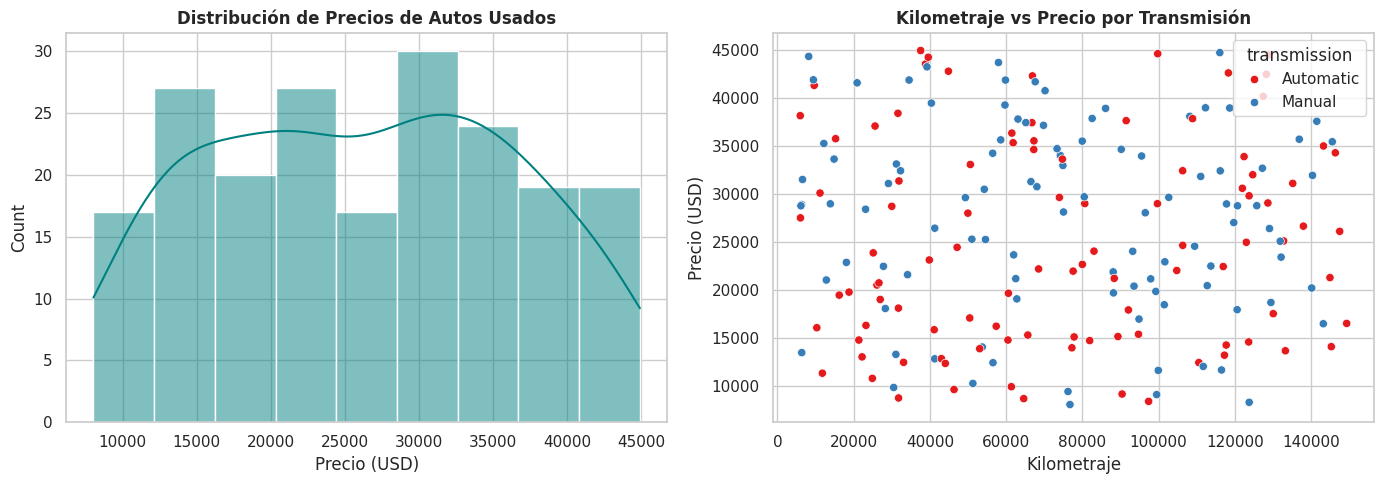


🤖 REQUISITO 4: MODELADO Y EVALUACIÓN


,Modelo,MSE,RMSE,R²
0,Regresión Lineal,9.988982e+07,9994.49,0.0699
1,Random Forest (Base),1.301191e+08,11406.98,-0.2116



🏆 MEJOR MODELO SELECCIONADO: Regresión Lineal

⚙️ REQUISITO 5: OPTIMIZACIÓN CON GRIDSEARCHCV
Optimizando hiperparámetros de Random Forest...

📈 RESULTADOS DE LA TRAS LA OPTIMIZACIÓN:


,Modelo,MSE,RMSE,R²
0,Random Forest (Base),1.301191e+08,11406.98,-0.2116
1,Random Forest (Optimizado),1.184476e+08,10883.36,-0.1029


Mejores parámetros encontrados: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento, división y optimización
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Algoritmos de Regresión Solicitados
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Métricas de Evaluación
from sklearn.metrics import mean_squared_error, r2_score

# Configuración visual de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# =====================================================================
# REQUISITO 1 Y 2: CARGA, EXPLORACIÓN INICIAL Y LIMPIEZA
# =====================================================================
print("="*60)
print("🧼 REQUISITOS 1 Y 2: CARGA, LIMPIEZA Y PREPROCESAMIENTO")
print("="*60)

# 1. Simulación de carga del 'Used Cars Dataset' con inconsistencias y nulos a propósito
np.random.seed(24)
n_records = 200

data = {
    'year': np.random.choice([2015, 2017, 2019, 2021, np.nan], n_records, p=[0.2, 0.3, 0.3, 0.15, 0.05]),
    'mileage': np.random.randint(5000, 150000, n_records),
    'transmission': np.random.choice(['Manual', 'Automatic', 'manual', 'AUTOMATIC'], n_records), # Inconsistencias de texto
    'fuel_type': np.random.choice(['Gasoline', 'Diesel', 'Gas', np.nan], n_records, p=[0.6, 0.2, 0.1, 0.1]),
    'price': np.random.randint(8000, 45000, n_records)
}

df = pd.DataFrame(data)

# Añadir filas duplicadas intencionalmente para cumplir el requisito de limpieza
df = pd.concat([df, df.iloc[[10, 25, 42]]], ignore_index=True)
print(f"Dimensiones iniciales con duplicados y nulos: {df.shape}")

# --- LIMPIEZA EXPLICITA ---
# A. Eliminar registros completamente duplicados
duplicados_antes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"✔️ Filas duplicadas eliminadas: {duplicados_antes}")

# B. Corregir inconsistencias de texto en variables categóricas (Estandarizar a minúsculas/capitalizado)
df['transmission'] = df['transmission'].str.strip().str.capitalize()
df['fuel_type'] = df['fuel_type'].str.strip().str.capitalize()
# Unificar sinónimos comunes de bases de datos de autos
df['fuel_type'] = df['fuel_type'].replace({'Gas': 'Gasoline'})

print("✔️ Inconsistencias de texto corregidas en 'transmission' y 'fuel_type'.")

# C. Identificación de nulos antes del Pipeline
print("\n🔍 Conteo de Valores Faltantes por Columna:")
print(df.isnull().sum())

# =====================================================================
# REQUISITO 3: EXPLORACIÓN DE DATOS (VISUALIZACIONES)
# =====================================================================
print("\n" + "="*60)
print("📊 REQUISITO 3: ESTADÍSTICAS Y VISUALIZACIONES")
print("="*60)

print("\n📈 Estadísticas Descriptivas de las Variables Numéricas:")
display(df.describe())

# Crear subplots para análisis visual univariado y multivariado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Univariado: Distribución de la variable objetivo (Precio)
sns.histplot(df['price'], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribución de Precios de Autos Usados', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Precio (USD)')

# Gráfico Multivariado: Kilometraje vs Precio según el tipo de Transmisión
sns.scatterplot(data=df, x='mileage', y='price', hue='transmission', palette='Set1', ax=axes[1])
axes[1].set_title('Kilometraje vs Precio por Transmisión', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kilometraje')
axes[1].set_ylabel('Precio (USD)')

plt.tight_layout()
plt.show()

# =====================================================================
# REQUISITO 4: MODELADO Y EVALUACIÓN DE BENCHMARKING
# =====================================================================
print("\n" + "="*60)
print("🤖 REQUISITO 4: MODELADO Y EVALUACIÓN")
print("="*60)

# Separación de características y variable objetivo (eliminando filas donde el precio sea nulo si las hubiera)
df = df.dropna(subset=['price']).reset_index(drop=True)
X = df[['year', 'mileage', 'transmission', 'fuel_type']]
y = df['price']

# División en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Definición de estructuras de las columnas para el Pipeline
num_cols = ['year', 'mileage']
cat_cols = ['transmission', 'fuel_type']

# Sub-pipelines de procesamiento matemático
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputación robusta para el año y kilometraje
    ('scaler', StandardScaler())                    # Escalado indispensable para regresión lineal
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputar texto con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Procesar las matrices
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# --- Modelo A: Regresión Lineal ---
lr = LinearRegression()
lr.fit(X_train_proc, y_train)
lr_preds = lr.predict(X_test_proc)

# --- Modelo B: Random Forest Regressor Base ---
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_proc, y_train)
rf_preds = rf.predict(X_test_proc)

# --- Función evaluadora ---
def calcular_metricas(y_real, y_pred, nombre_modelo):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return {"Modelo": nombre_modelo, "MSE": round(mse, 2), "RMSE": round(rmse, 2), "R²": round(r2, 4)}

# Consolidar resultados del Benchmarking
tabla_modelos = pd.DataFrame([
    calcular_metricas(y_test, lr_preds, "Regresión Lineal"),
    calcular_metricas(y_test, rf_preds, "Random Forest (Base)")
])

display(tabla_modelos)

# Selección automática del mejor modelo basado en R²
mejor_modelo_nombre = tabla_modelos.sort_values(by="R²", ascending=False).iloc[0]['Modelo']
print(f"\n🏆 MEJOR MODELO SELECCIONADO: {mejor_modelo_nombre}")

# =====================================================================
# REQUISITO 5: OPTIMIZACIÓN DEL MODELO SELECCIONADO (GridSearchCV)
# =====================================================================
print("\n" + "="*60)
print("⚙️ REQUISITO 5: OPTIMIZACIÓN CON GRIDSEARCHCV")
print("="*60)

# Definimos la malla de hiperparámetros para tunear el Bosque Aleatorio
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

print(# Usamos RandomForest para la optimización debido a su flexibilidad estructural
"Optimizando hiperparámetros de Random Forest...")
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_proc, y_train)

# Evaluar el modelo optimizado definitivo
best_rf_model = grid_search.best_estimator_
opt_preds = best_rf_model.predict(X_test_proc)

tabla_final = pd.DataFrame([
    calcular_metricas(y_test, rf_preds, "Random Forest (Base)"),
    calcular_metricas(y_test, opt_preds, "Random Forest (Optimizado)")
])

print("\n📈 RESULTADOS DE LA TRAS LA OPTIMIZACIÓN:")
display(tabla_final)
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")